### Import Required Libraries and Classes

This cell imports the Python libraries and project classes required for the data streaming, database, and dashboard components.


In [1]:
%matplotlib inline

import sys
import time
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("..")

from data_service.datacollection import StreamingSimulator
from data_service.database_manager import Database
from web_ui.web_ui_interface import RobotDashboard

Project initialized successfully.


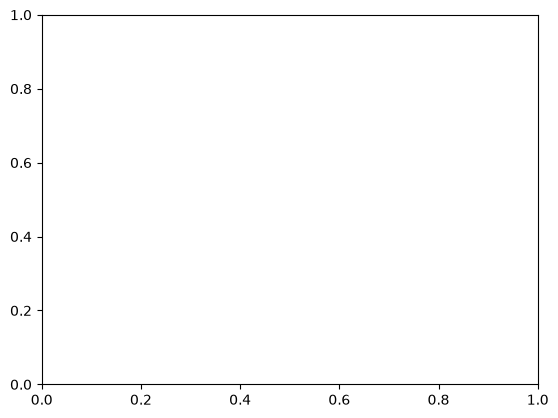

In [2]:
ss = StreamingSimulator("../data/RMBR4-2_export_test.csv")
dashboard = RobotDashboard()


print("Project initialized successfully.")


### Stream One Data Point

This cell reads one record from the CSV file to simulate receiving a single data point from the robot.


In [3]:
data_point = ss.nextDataPoint()
print(data_point)
display(data_point)


     Trait  Axis #1  Axis #2  Axis #3  Axis #4  Axis #5  Axis #6  Axis #7  \
0  current      0.0      0.0      0.0      0.0      0.0      0.0      0.0   

   Axis #8  Axis #9  Axis #10  Axis #11  Axis #12  Axis #13  Axis #14  \
0      0.0      NaN       NaN       NaN       NaN       NaN       NaN   

                       Time  
0  2022-10-17T12:18:23.660Z  


,Trait,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8,Axis #9,Axis #10,Axis #11,Axis #12,Axis #13,Axis #14,Time
0,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:23.660Z


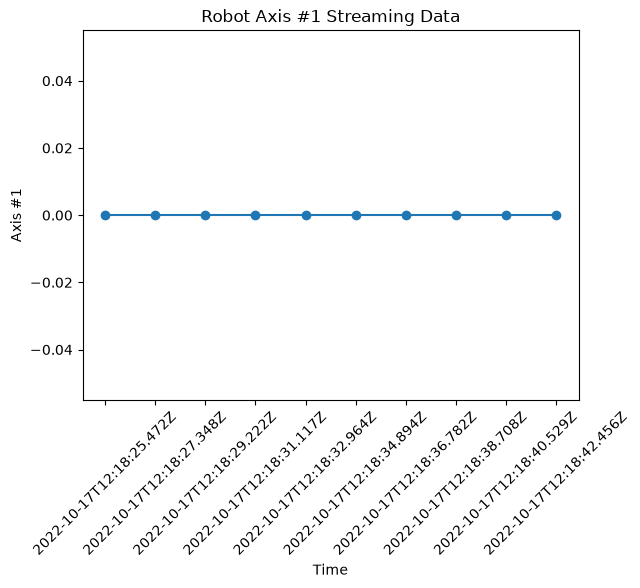

In [4]:
for i in range(10):

    data_point = ss.nextDataPoint()

    if data_point is None:
        break

    print("New data point:")
    print(data_point)

    # Open database connection
    db = Database()
     # Create table if needed
    db.createTable(data_point)

    # Insert the new record
    db.insertDataPoint(data_point)

    # Update dashboard
    dashboard.updateDashboard(data_point)
  

     # Close database connection
    db.connection.close()

    # Wait 2 seconds before reading the next record
    time.sleep(2)

In [7]:
db = Database()

db.cursor.execute("SELECT COUNT(*) FROM robot_data")
count = db.cursor.fetchone()[0]

print("Records currently in database:", count)

db.connection.close()

Records currently in database: 0


### Clear Demonstration Records

The previous streaming demonstration inserted a small number of sample readings into the database.

These demonstration records are cleared before loading the complete dataset so that the database contains only the full dataset for the remaining analysis.

In [6]:
db = Database()

db.cursor.execute("DELETE FROM robot_data")
db.connection.commit()

print("Streaming demo records cleared.")

db.connection.close()

Streaming demo records cleared.


In [8]:
all_data = pd.read_csv("../data/RMBR4-2_export_test.csv")

print("Total records in CSV:", len(all_data))

Total records in CSV: 39672


### Load Complete Dataset into Database

The complete robot dataset is loaded from the CSV file into the Neon database.

This cell creates the database table if needed and inserts all **39,672 records** in batches. Batch insertion is used to store the complete dataset efficiently while reducing repeated database operations.

In [9]:
db = Database()

db.createTable(all_data.iloc[[0]])
db.insertBulkData(all_data)

db.connection.close()

500 records inserted...
1000 records inserted...
1500 records inserted...
2000 records inserted...
2500 records inserted...
3000 records inserted...
3500 records inserted...
4000 records inserted...
4500 records inserted...
5000 records inserted...
5500 records inserted...
6000 records inserted...
6500 records inserted...
7000 records inserted...
7500 records inserted...
8000 records inserted...
8500 records inserted...
9000 records inserted...
9500 records inserted...
10000 records inserted...
10500 records inserted...
11000 records inserted...
11500 records inserted...
12000 records inserted...
12500 records inserted...
13000 records inserted...
13500 records inserted...
14000 records inserted...
14500 records inserted...
15000 records inserted...
15500 records inserted...
16000 records inserted...
16500 records inserted...
17000 records inserted...
17500 records inserted...
18000 records inserted...
18500 records inserted...
19000 records inserted...
19500 records inserted...
20000 

### Retrieve Data From Database

The streamed robot readings are stored in the Neon database for persistence. This cell retrieves the stored readings so that the complete dataset can be analyzed for robot behaviour, electrical activity, and potential patterns.


In [10]:
db = Database()

full_df = db.fetch_all()

print("Total readings retrieved from Neon:", len(full_df))

display(full_df.head())

db.connection.close()

c:\Users\pree0\OneDrive\Desktop\Conestoga_Projects\Foundations_Of_Machine_Learning_Frameworks\DataEngineeringOneAssignment\src\data_service\database_manager.py:102: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(


Total readings retrieved from Neon: 39672


,id,trait,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8,axis_9,axis_10,axis_11,axis_12,axis_13,axis_14,time
0,32379,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,2022-10-17T12:48:37.367Z
1,34505,current,0.36482,11.43911,3.58461,0.43876,4.43922,0.07743,8.09655,0.0981,None,None,None,None,None,None,2022-10-17T14:05:32.843Z
2,34506,current,1.09447,37.26937,6.43121,2.40027,19.40867,0.12905,0.03577,0.0981,None,None,None,None,None,None,2022-10-17T14:05:34.801Z
3,34507,current,0.33876,1.84502,11.59726,0.30971,0.72266,2.68418,0.52467,0.07848,None,None,None,None,None,None,2022-10-17T14:05:36.679Z
4,34508,current,0.85994,2.10859,0.15814,0.2839,0.67104,0.90333,8.09655,0.05886,None,None,None,None,None,None,2022-10-17T14:05:38.577Z


### Data Patterns and Tendencies

The analysis of the robot electrical readings shows the following patterns:

* The readings for all 8 axes are mostly low or zero.
* The average reading is higher than the median for all axes, showing that occasional higher readings increase the average.
* Axis #2 and Axis #3 have higher average readings compared with the other axes.
* Axis #8 has the lowest average reading.
* The maximum readings vary between the axes, showing different levels of electrical activity.
* The bar chart provides a visual comparison of the average electrical activity across the eight axes.

These patterns can be used as a baseline for identifying unusual readings and monitoring the robot's condition.


In [11]:
# Select the electrical axes
electrical_axes = [
    "axis_1", "axis_2", "axis_3", "axis_4",
    "axis_5", "axis_6", "axis_7", "axis_8"
]

# Convert the axis columns to numeric values
for axis in electrical_axes:
    full_df[axis] = pd.to_numeric(full_df[axis], errors="coerce")

# Calculate basic statistics
pattern_summary = full_df[electrical_axes].describe().T

display(pattern_summary)


,count,mean,std,min,25%,50%,75%,max
axis_1,39672.0,0.725743,2.162120,0.0,0.0,0.0,0.31271,23.60930
axis_2,39672.0,3.613374,6.879962,0.0,0.0,0.0,4.21719,51.71323
axis_3,39672.0,2.710336,5.111901,0.0,0.0,0.0,4.58619,41.85556
axis_4,39672.0,0.620222,1.574897,0.0,0.0,0.0,0.51619,15.66630
axis_5,39672.0,0.954521,2.100186,0.0,0.0,0.0,0.80009,20.75076
axis_6,39672.0,0.599427,1.815498,0.0,0.0,0.0,0.36133,20.93142
axis_7,39672.0,0.870145,2.166811,0.0,0.0,0.0,0.31003,8.10848
axis_8,39672.0,0.102214,0.423075,0.0,0.0,0.0,0.07848,5.90564


### Visualize Average Axis Readings

This cell creates a bar chart of the average electrical reading for each robot axis. The chart provides a visual comparison of the typical electrical activity across the eight axes.


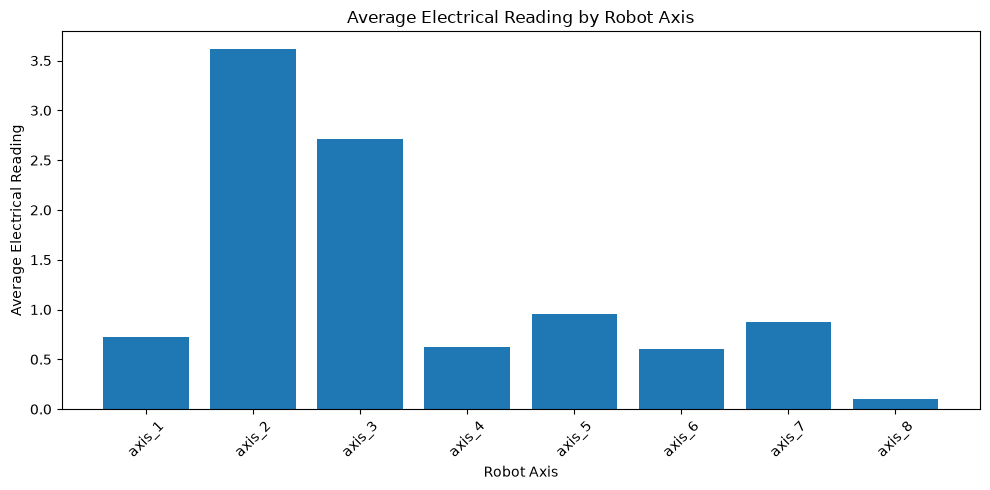

In [13]:
plt.figure(figsize=(10, 5))

plt.bar(
    electrical_axes,
    pattern_summary["mean"]
)

plt.title("Average Electrical Reading by Robot Axis")
plt.xlabel("Robot Axis")
plt.ylabel("Average Electrical Reading")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# energy calculation
### Calculate Total Electrical Reading

This cell combines the electrical readings from Axis 1 to Axis 8 for each robot reading. The resulting value provides a simple measure of the robot's overall electrical activity and will be used to visualize its behaviour over time.


In [14]:
full_df["Total_Electrical_Reading"] = full_df[electrical_axes].sum(axis=1)

display(
    full_df[
        ["time"] + electrical_axes + ["Total_Electrical_Reading"]
    ].head()
)

,time,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8,Total_Electrical_Reading
0,2022-10-17T12:48:37.367Z,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
1,2022-10-17T14:05:32.843Z,0.36482,11.43911,3.58461,0.43876,4.43922,0.07743,8.09655,0.09810,28.53860
2,2022-10-17T14:05:34.801Z,1.09447,37.26937,6.43121,2.40027,19.40867,0.12905,0.03577,0.09810,66.86691
3,2022-10-17T14:05:36.679Z,0.33876,1.84502,11.59726,0.30971,0.72266,2.68418,0.52467,0.07848,18.10074
4,2022-10-17T14:05:38.577Z,0.85994,2.10859,0.15814,0.28390,0.67104,0.90333,8.09655,0.05886,13.14035


### Robot Electrical Activity Over Time

This cell plots the total electrical activity of the robot over time using the readings stored in the Neon database. The visualization helps summarize changes in robot behaviour and identify periods of higher electrical activity.


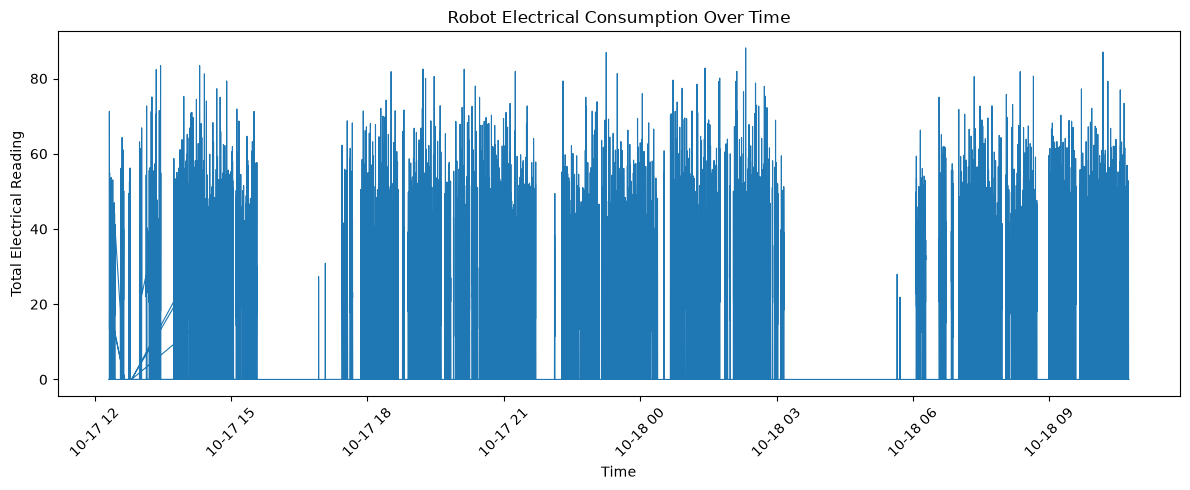

In [15]:
# Convert the time column to datetime
full_df["time"] = pd.to_datetime(full_df["time"])

plt.figure(figsize=(12, 5))

plt.plot(
    full_df["time"],
    full_df["Total_Electrical_Reading"],
    linewidth=0.8
)

plt.title("Robot Electrical Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Total Electrical Reading")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [17]:
import time

for i in range(5):

    data_point = ss.nextDataPoint()

    if data_point is None:
        break

    print("New data point:")
    print(data_point)

    time.sleep(2)

New data point:
      Trait  Axis #1  Axis #2  Axis #3  Axis #4  Axis #5  Axis #6  Axis #7  \
16  current      0.0      0.0      0.0      0.0      0.0      0.0      0.0   

    Axis #8  Axis #9  Axis #10  Axis #11  Axis #12  Axis #13  Axis #14  \
16      0.0      NaN       NaN       NaN       NaN       NaN       NaN   

                        Time  
16  2022-10-17T12:18:53.706Z  
New data point:
      Trait  Axis #1  Axis #2  Axis #3  Axis #4  Axis #5  Axis #6  Axis #7  \
17  current      0.0      0.0      0.0      0.0      0.0      0.0      0.0   

    Axis #8  Axis #9  Axis #10  Axis #11  Axis #12  Axis #13  Axis #14  \
17      0.0      NaN       NaN       NaN       NaN       NaN       NaN   

                        Time  
17  2022-10-17T12:18:55.575Z  
New data point:
      Trait  Axis #1  Axis #2  Axis #3  Axis #4  Axis #5  Axis #6  Axis #7  \
18  current      0.0      0.0      0.0      0.0      0.0      0.0      0.0   

    Axis #8  Axis #9  Axis #10  Axis #11  Axis #12  Axis #1